## Preprocessing Small Tabular Datasets

In this section, we will begin by loading a CSV dataset that contains detailed information obtained from mobile network drive tests. In the context of mobile networks, a drive test is a monitoring protocol that gathers measurements and statistics on network performance when a testing mobile device downloads a file of a specific size. The dataset includes various variables that assess different aspects of mobile network performance, such as throughput, latency, TCP behavior, and radio performance.

Once the dataset is loaded, we apply several preprocessing steps to prepare it for the upcoming machine-learning stages. Specifically, the preprocessing stage involves handling missing data, removing constant columns, and detecting multicollinearity. To this end,  we utilize the pandas library, a Python tool for working with tabular data. In pandas, data is stored in DataFrames, which are two-dimensional, labeled data structures that are particularly useful for tasks such as exploratory data analysis and data preprocessing.

Before proceeding, we assume that the corresponding virtual environment has been activated and that the required libraries, such as pandas, have been installed.

## Import libraries

The first lines of code import **Pandas** and **NumPy** libraries. **Pandas** is a Python package that provides efficient and flexible tools for working with tabular data, such as CSV files or database tables. It allows users to manipulate and analyze data in structures called DataFrames, which are similar to spreadsheets.

**NumPy**, on the other hand, is a library that supports numerical operations and offers functions to work with arrays and matrices. NumPy is essential for performing mathematical calculations on large datasets, which can be particularly useful for data analysis and machine learning tasks.

In [1]:
import pandas as pd
import numpy as np

# Ploting libraries
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor 

# Scikit-learn libraries
from sklearn import mixture

import warnings
warnings.filterwarnings('ignore')

<div class="alert alert-block alert-warning">Including a code cell at the beginning of the notebook to import all requisite libraries is advisable, but it is not mandatory.</div>

## Load Dataset

Subsequently, we use the ``pandas.read_csv`` function, which loads the dataset from a CSV file into a table-like structure called a DataFrame. In our case, ``DatasetA.csv`` contains hundreds of measurements and statistics captured during drive tests. Nokia collected this dataset across multiple European countries in 2023. This dataset does not include sensitive information about individuals or operators. 

From this dataset, we filter observations (i.e., data table rows) where the target operator is ``Operator1``, the test type is ``Capacity DL``, and the test qualifier is marked as ``SUCCESS``. In the context of mobile networks, the ``Capacity DL`` test assesses how much data the network can deliver to mobile users during the downlink (data transmitted from the network to the mobile device under test). This test is crucial for evaluating network throughput. 

Our analysis focuses on the throughput variable (labeled ``transfer_datarate``), the target key performance indicator (KPI). Notice that we then remove any rows where the throughput value is either missing (NaN) or negative, as these do not provide valid data for analysis. Finally, we select only the columns with numeric data types needed for further statistical analysis or modeling.

In [2]:
print('-----------------------------------------------------------------')
print('LOADING DATASET A FILE DOWNLOAD DATASET')
data_file  = 'd2_Operator1_HttpTransferUL'
input_data = 'data/raw_data/' + data_file + '.csv'
data = pd.read_csv(input_data, encoding = "ISO-8859-1", sep=",", decimal='.', low_memory = False)
print('-----------------------------------------------------------------')

-----------------------------------------------------------------
LOADING DATASET A FILE DOWNLOAD DATASET
-----------------------------------------------------------------


## Variable Selection

This stage requires an understanding of the dataset’s structure and variable names. Our study focuses on extracting specific data columns (variables or features) that provide the target KPI and relevant statistics. Specifically, we collect data related to the information transferred from the testing mobile device to the server (``a2b``) and from the server to the testing device (``b2a``). In addition, our code gathers indicator statistics, such as the minimum (``_min``), the 25th percentile 25 (``_25.``), the median (``_50.``), the 75th percentile (``_75.``), the maximum (``_max``), the average (``_avg``), and the sum (``_sum``). After gathering the relevant variables and statistics, we remove certain columns that contain measurements at specific test stages, such as ``VolStep``, ``TimeStep``, ``FirstSec``, and ``FirstMB``. These columns are not necessary for our analysis at this point. We use the ``DataFrame.columns.str.contains()`` function to identify columns. This function allows us to find column names that contain specific strings. Afterward, the code eliminates duplicated columns.

In [3]:
data = data[data.columns[data.columns.str.contains('transfer.datarate')|
                         data.columns.str.contains('.a2b')|
                         data.columns.str.contains('.b2a')|
                         data.columns.str.contains('.min')|
                         data.columns.str.contains('.25.')|
                         data.columns.str.contains('.50.')|
                         data.columns.str.contains('.75.')|
                         data.columns.str.contains('.max')|
                         data.columns.str.contains('.avg')|
                         data.columns.str.contains('.sum')]]

# Remove columns
data = data[data.columns[~data.columns.str.contains('volstep')]]
data = data[data.columns[~data.columns.str.contains('timestep')]]
data = data[data.columns[~data.columns.str.contains('firstsec')]]
data = data[data.columns[~data.columns.str.contains('firstmb')]]

print('-----------------------------------------------------------------')
print('Before removing duplicates\t Size:(%d, %d)'%(data.shape[0], data.shape[1]))
data = data.T.drop_duplicates().T
print('After removing duplicates\t Size:(%d, %d)'%(data.shape[0], data.shape[1]))
print('-----------------------------------------------------------------')

-----------------------------------------------------------------
Before removing duplicates	 Size:(688, 166)
After removing duplicates	 Size:(688, 166)
-----------------------------------------------------------------


## Format Ajustment

This code standardizes variable names by converting them to lowercase and using dots as word separation characters.

In [4]:
data.columns= data.columns.str.lower()
original_feat = list(data.columns)
for i in range(len(original_feat)):
    data.rename(columns={original_feat[i]: original_feat[i].replace('_','.')}, inplace=True)
    data.rename(columns={original_feat[i]: original_feat[i].replace(' ','.')}, inplace=True) 

original_feat = list(data.columns)
for i in range(len(original_feat)):
    data.rename(columns={original_feat[i]: original_feat[i].replace('...','.')}, inplace=True)
    data.rename(columns={original_feat[i]: original_feat[i].replace('..','.')}, inplace=True)

## Data Preprocessing

In general, measurements and statistics are not always stored correctly, leading to missing values (null cells) in the dataset. A column with many null values does not provide meaningful information for data analysis or machine learning models, leading to inaccurate estimations and nonfunctional models. Thus, we remove columns with more than 1% missing values because such columns would provide insufficient information for analysis. For the remaining columns with missing values, we fill in the gaps using the median of the column. The median is chosen because it is less affected by extreme values (outliers) and provides a more stable estimate for missing data.

Similarly, columns with the same value in every row do not provide helpful information for analysis, as they lack variability, which is critical for identifying patterns in machine learning models. Therefore, we remove any columns with a unique value across all rows.

In [5]:
data1 = data.copy()
target_kpi = 'transfer.datarate'
kpi_aux = data1[target_kpi] 

data1 = data1.loc[:,data1.columns[data1.columns != 'unnamed:.0']]
print('Input dataset \t\t\t\t Size: (%d, %d)'%(data1.shape[0], data1.shape[1]))

# Remove cols with more than 1% of NA
data1 = data1.loc[:,data1.columns[data1.columns != target_kpi]]
data1 = data1.replace([np.inf, -np.inf], np.nan)
data1 = data1.loc[:, data1.columns[data1.isna().mean(axis=0) < 0.01]]
# Replace remaining null cells with the column median
data1 = data1.fillna(data1.median())
print('Remove cols with more than 1%% of Nans \t Size: (%d, %d)'%(data1.shape[0], data1.shape[1]))

# Remove constant columns
data2 = data1.loc[:, (data1.std(axis=0) != 0).values]
print('Remove cols with a single value \t Size: (%d, %d)'%(data2.shape[0], data2.shape[1]))

Input dataset 				 Size: (688, 166)
Remove cols with more than 1% of Nans 	 Size: (688, 95)
Remove cols with a single value 	 Size: (688, 94)


## Multicollinearity Detection and Removal

At this step, the procedure eliminates columns with **multicollinearity**, a limitation that arises when two or more independent variables in the dataset are highly correlated. This limitation can distort the results of a regression model, leading to unreliable coefficient estimates and, consequently, distorting the individual effects of the input features on the model.

To address multicollinearity, we have developed an algorithm that removes columns one by one based on their **variance inflation factor (VIF).** At each iteration, the algorithm identifies the column with the highest VIF and removes it. This process continues until all remaining columns have a VIF below a predefined threshold, which we have set at 1000 in our case. By calculating VIF, we can effectively identify and remove columns with high multicollinearity, thereby ensuring that our model is more accurate and reliable. It's worth noting that this algorithm may take several minutes to complete.

Finally, We save the clean dataset in a CSV file.

In [6]:
vif_vector = np.array([variance_inflation_factor(data2.values, i) for i in range(len(data2.columns))]).reshape(-1,1)
k = 1
print('-----------------------------------------------------------------')
print('Removed Features')
print('-----------------------------------------------------------------')
while (np.max(vif_vector) > 1000):
    col2rem = data2.columns[np.argmax(vif_vector)]
#     print('%d & %s & %E \\\\'%(k, col2rem, np.max(vif_vector))) # For LaTeX tabular
    print('%d \t & \t %s '%(k, col2rem))
    data2 = data2.loc[:, data2.columns != col2rem]
    vif_vector = np.array([variance_inflation_factor(data2.values, i) for i in range(len(data2.columns))]).reshape(-1,1)
    k += 1
data3 = data2.loc[:, data2.columns[~np.isinf(vif_vector).reshape(-1)]]
data3[target_kpi] = kpi_aux
data3.shape

-----------------------------------------------------------------
Removed Features
-----------------------------------------------------------------
1 	 & 	 total.packets.a2b 
2 	 & 	 total.packets.b2a 
3 	 & 	 ack.pkts.sent.a2b 
4 	 & 	 pure.acks.sent.a2b 
5 	 & 	 sack.pkts.sent.a2b 
6 	 & 	 dsack.pkts.sent.a2b 
7 	 & 	 unique.bytes.sent.a2b 
8 	 & 	 unique.bytes.sent.b2a 
9 	 & 	 syn.pkts.sent.a2b 
10 	 & 	 truncated.packets.a2b 
11 	 & 	 truncated.data.b2a 
12 	 & 	 actual.data.bytes.a2b 
13 	 & 	 rtt.full.sz.max.a2b 
14 	 & 	 rtt.full.sz.smpls.b2a 
15 	 & 	 actual.data.pkts.b2a 
16 	 & 	 rtt.from.3whs.a2b 
17 	 & 	 max.segm.size.a2b 
18 	 & 	 initial.window.pkts.a2b 
19 	 & 	 rexmt.data.pkts.a2b 
20 	 & 	 avg.win.adv.a2b 
21 	 & 	 truncated.data.a2b 
22 	 & 	 truncated.packets.b2a 
23 	 & 	 avg.segm.size.b2a 
24 	 & 	 rtt.from.3whs.b2a 
25 	 & 	 avg.segm.size.a2b 
26 	 & 	 pure.acks.sent.b2a 
27 	 & 	 rtt.full.sz.avg.b2a 
28 	 & 	 initial.window.bytes.b2a 
29 	 & 	 min.non.zero.owi

(688, 62)

## Detection and Removal of Features Correlated with the KPI

Features correlated to the KPI typically induce overfitting in machine-learning models, leading to erroneous interpretations. In this stage, we aim to detect and remove features highly correlated with the KPI at this stage. To this end, we build the vector of correlation factors, where each entry is computed as follows:

$$ c_i = 1 - \left| \frac{\mathbf{cov}(\mathbf{x}_i, \mathbf{y})}{\sigma_{\mathbf{x}_i} \sigma_{\mathbf{y}}} \right|$$

where $\mathbf{y}$ is target KPI vector and $\mathbf{x}_i$ denotes a vector describing the $i$-th feature, $\sigma_{\mathbf{x}_i}$ is the standard deviation of the $i$-th feature, and $\sigma_{\mathbf{y}}$ is the standard deviation of the target KPI. Notice that every correlation factor $c_i$ can be described as one minus the [Pearson correlation coefficient](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient) between the target KPI and the $i$-th feature. In practical terms, we compute the correlation factor matrix (one minus the Pearson correlation matrix) and extract the vector corresponding to the target KPI.

In [7]:
# Compute the matrix of correlation factors and extract the vector related to the target KPI 
corr_matrix = 1 - data3.corr(method='pearson').abs()
corr_vector = corr_matrix[target_kpi].to_numpy().reshape(-1,1)

## Gaussian Mixture

In this work, we use a clustering method based on Gaussian mixture models (GMMs) to identify features highly correlated with the KPI. In particular, a GMM assumes that the data entries are random samples generated by a mixture of a finite number of Gaussian distributions, each with different parameters. We implement the GMM-based clustering with the `mixture.GaussianMixture` function of the scikit-learn library. This method estimates the parameters of the Gaussian distributions using an Expectation-Maximization (EM) algorithm. Furthermore, it assigns each test data point to the most likely Gaussian distribution, where each Gaussian model represents a different cluster. 

It is essential to mention that the optimal number of clusters that best describe data is unknown. Furthermore, this method uses a random seed to select the method to initialize the parameters, which can result in different outcomes even when the same input data is used. To overcome this limitation, we implement a Monte Carlo approximation to detect the optimal number of clusters according to the Bayesian Information Criterion (BIC). More precisely, we estimate the average BIC curve along the number of clusters and detect the number of clusters that generate the minimum average BIC value. After determining the optimal number of clusters, we identify and remove features associated with the cluster with the lowest centroid.

In [8]:
eval_window = 40
iterations  = 50

# Monte Carlo Approximation to estimate the average BIC curve
max_num_clusters = np.min([eval_window + 1, len(corr_vector)])
bic_ite    = np.zeros((iterations, max_num_clusters - 1))
rand_stt   = np.random.randint(2**16, size=(iterations, max_num_clusters - 1)) 
for ii in range(iterations):
    for jj in range(1, max_num_clusters):
        gmm = mixture.GaussianMixture(n_components = jj,
                                      random_state = rand_stt[ii,jj-1])
        gmm.fit(corr_vector)
        bic_ite[ii,jj-1] = gmm.bic(corr_vector)
        
# Determining the optimal number of clusters
num_opt_clusters_bic = np.argmin(np.mean(bic_ite, axis=0)) + 1
minbic = np.min(np.mean(bic_ite, axis=0))
maxbic = np.max(np.mean(bic_ite, axis=0))

# Implement the optimal model
lowest_bic  = np.infty
bic         = []
for ii in range(iterations):
    gmm_bic = mixture.GaussianMixture(num_opt_clusters_bic,
                                      random_state = rand_stt[ii,num_opt_clusters_bic-1])
    gmm_bic.fit(corr_vector)
    bic.append(gmm_bic.bic(corr_vector))
    if bic[-1] < lowest_bic:
        lowest_bic = bic[-1]
        best_gmmb = gmm_bic
    clusters_bic = best_gmmb.predict(corr_vector)
    centroids_bic = best_gmmb.means_

# Identify the features highly correlated with the KPI
columns_to_remove_bic = data3.columns[(clusters_bic == np.argmin(centroids_bic))]

data4 = data3.copy()
if (len(np.unique(clusters_bic)) > 1):
    data4 = data4.loc[:, data4.columns[(clusters_bic != np.argmin(centroids_bic))]]
data4[target_kpi] = kpi_aux

output_file = 'data/clean_data/' + data_file + '_clean.csv'
data4.to_csv(output_file, index=False)
data4.shape

(688, 59)

### Results of the Feature Removal using GMM-based clustering

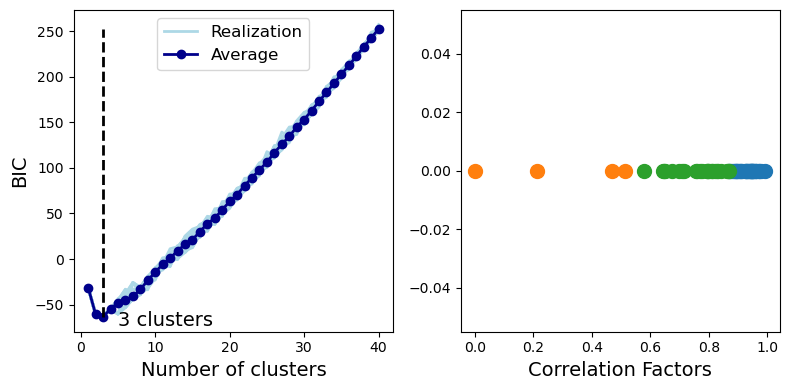

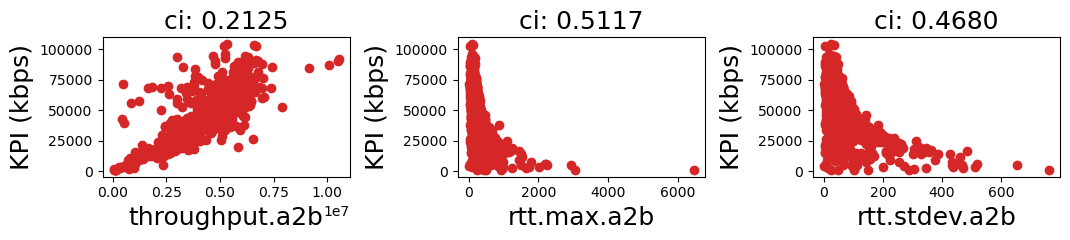

In [9]:
fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(1,2,1)
for ii in range(iterations):
    if (ii ==0):
        plt.plot(np.arange(1, max_num_clusters), bic_ite[ii,:], lw=2, c='lightblue', label='Realization')
    else:
        plt.plot(np.arange(1, max_num_clusters), bic_ite[ii,:], lw=2, c='lightblue')
plt.plot(np.arange(1, max_num_clusters), np.mean(bic_ite, axis=0), '-o',lw=2, c='darkblue', label='Average')
plt.plot([num_opt_clusters_bic, num_opt_clusters_bic], [minbic, maxbic],'k--', lw=2)
plt.xlabel('Number of clusters', fontsize=14)
plt.ylabel('BIC', fontsize=14)
plt.text(num_opt_clusters_bic + 2, np.mean(bic_ite, axis=0)[num_opt_clusters_bic-1]-10, str(num_opt_clusters_bic) + ' clusters', fontsize=14)
plt.legend(fontsize=12, loc='upper center')

ax  = fig.add_subplot(1,2,2)
for i in range(len(np.unique(clusters_bic))):
    plt.scatter(corr_vector[clusters_bic == i], np.zeros(len(corr_vector[clusters_bic == i])), s=100)
plt.xlabel('Correlation Factors', fontsize=14)
    
fig.tight_layout()
plt.show()


ncols = 7
nrows = ((len(columns_to_remove_bic) - 1) // ncols) + 1
fig = plt.figure(figsize=(25,2.50*nrows), tight_layout=True)
for ii in range(len(columns_to_remove_bic)-1):
    ax = fig.add_subplot(nrows,ncols,ii+1)
    plt.plot(data[columns_to_remove_bic[ii]], data[target_kpi],'o', color='tab:red')
    plt.xlabel(columns_to_remove_bic[ii], fontsize=18)
    plt.ylabel('KPI (kbps)', fontsize=18)
    plt.title('ci: %.4f'%(corr_matrix[columns_to_remove_bic[ii]][-1]), fontsize=18)
fig.tight_layout()
plt.show()